K-means in python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler


In [2]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

In [3]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [ ]:
# troviamo il numero k ottimale attraverso elbow method

wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_std)
    wcss.append(kmeans.inertia_)

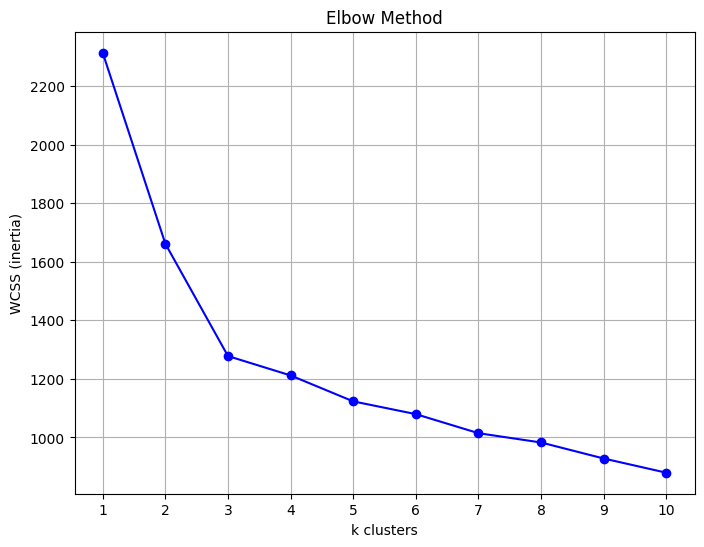

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(k_values, wcss, marker="o", color="blue")
plt.xlabel("k clusters")
plt.ylabel("WCSS (inertia)")
plt.xticks(k_values)
plt.title("Elbow Method")
plt.grid()
plt.show()

In [9]:
# andiamo a fare il k-means con k=3 trovato
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_std)
centroids = kmeans.cluster_centers_
iter = kmeans.n_iter_
print(f"Iterations:\t{iter}")
print(f"Centroidi:\t{centroids}")

Iterations:	7
Centroidi:	[[-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]
 [ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]]


In [10]:
# rappresentazione grafica dei dati con PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

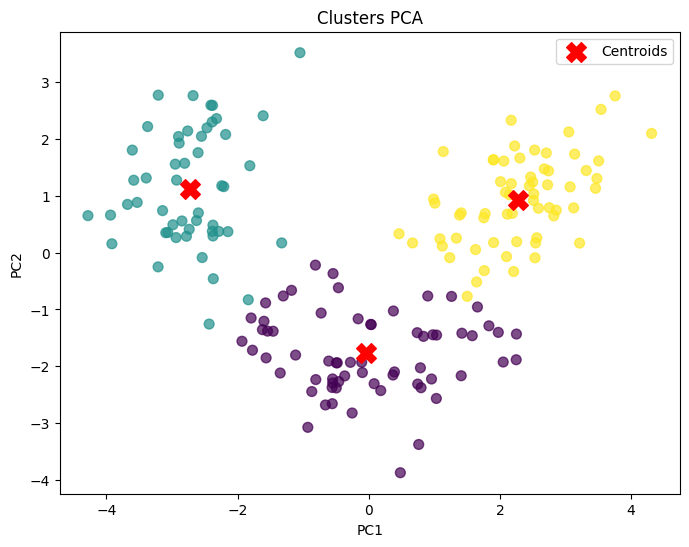

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
# dobbiamo anche ridurre i centroidi con PCA per poterli visualizzare
plt.scatter(
    pca.transform(centroids)[:, 0], 
    pca.transform(centroids)[:, 1], 
    c='red', 
    marker='X', 
    s=200, 
    label='Centroids'
)
plt.title("Clusters PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

C:\Users\chian\AppData\Local\Temp\ipykernel_24688\671863004.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


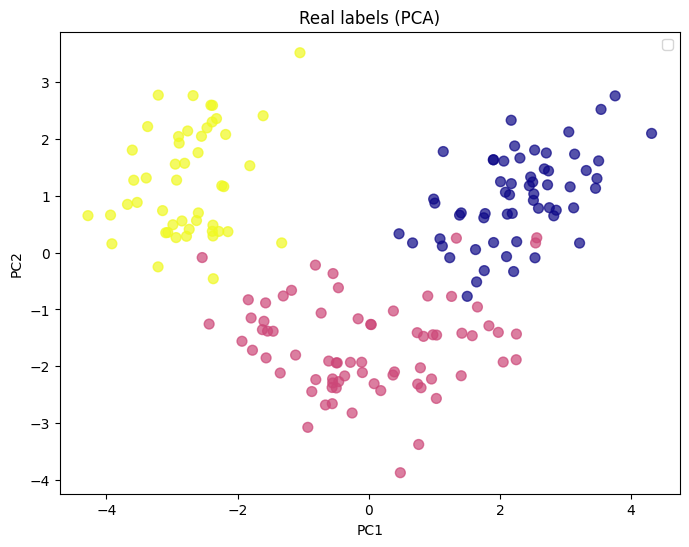

In [12]:
# vediamo le label originali del grafico
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', s=50, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Real labels (PCA)")
plt.legend()
plt.show()